# Reinforcement Learning — Category Recap

> **Goal:** learn a policy $\pi(a \mid s)$ that maximises long-term reward in a Markov decision process.

This notebook ties together the three RL notebooks
([33](illustrated_33_reinforcement_learning_qlearning.ipynb)–[35](illustrated_35_reinforcement_learning_policy_gradient.ipynb))
into one decision panel.

**Algorithms covered:**

| # | Algorithm | Notebook | Family |
|---|---|---|---|
| 33 | Tabular Q-Learning | [qlearn](illustrated_33_reinforcement_learning_qlearning.ipynb) | Value-based, off-policy, table |
| 34 | DQN | [dqn](illustrated_34_reinforcement_learning_dqn.ipynb) | Value-based, off-policy, neural net |
| 35 | REINFORCE / PG | [pg](illustrated_35_reinforcement_learning_policy_gradient.ipynb) | Policy-based, on-policy |


## Cheat-sheet — reinforcement learning landscape

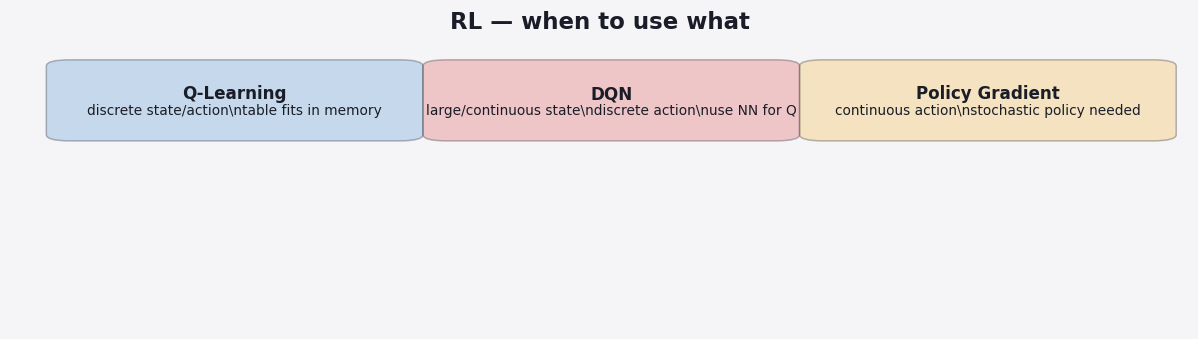

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis('off')
ax.text(0.5, 0.96, 'RL — when to use what', ha='center', fontsize=15, weight='bold')
items = [('Q-Learning', 'discrete state/action\\ntable fits in memory'), ('DQN', 'large/continuous state\\ndiscrete action\\nuse NN for Q'), ('Policy Gradient', 'continuous action\\nstochastic policy needed')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Comparison

| Property | Tabular Q-Learning | DQN | REINFORCE | A2C / PPO |
|---|---|---|---|---|
| State space | small, finite | huge / pixels | any | any |
| Action space | discrete | discrete | discrete or continuous | discrete or continuous |
| On / off policy | off | off (replay) | on | on |
| Sample efficiency | high (small env) | medium | low (high variance) | medium |
| Stability tricks | none | replay + target net | baseline + entropy | clipped objective + GAE |
| Learns explicit policy | derived from $Q$ | derived from $Q$ | ✅ | ✅ |
| Continuous actions | ❌ | ❌ | ✅ | ✅ |

---
## Decision rule

```
Tiny finite MDP, want a clear demo?
├── Yes  →  tabular Q-learning  (or SARSA on cliff-walking)
└── No   →  discrete actions, large/pixel state?
            ├── Yes  →  DQN  (with Double DQN + Dueling + Prioritised Replay extras)
            └── No   →  continuous actions or stochastic policy needed?
                        ├── Yes  →  PPO / SAC / TD3   (REINFORCE only as warm-up)
                        └── No   →  A2C as a robust default
```


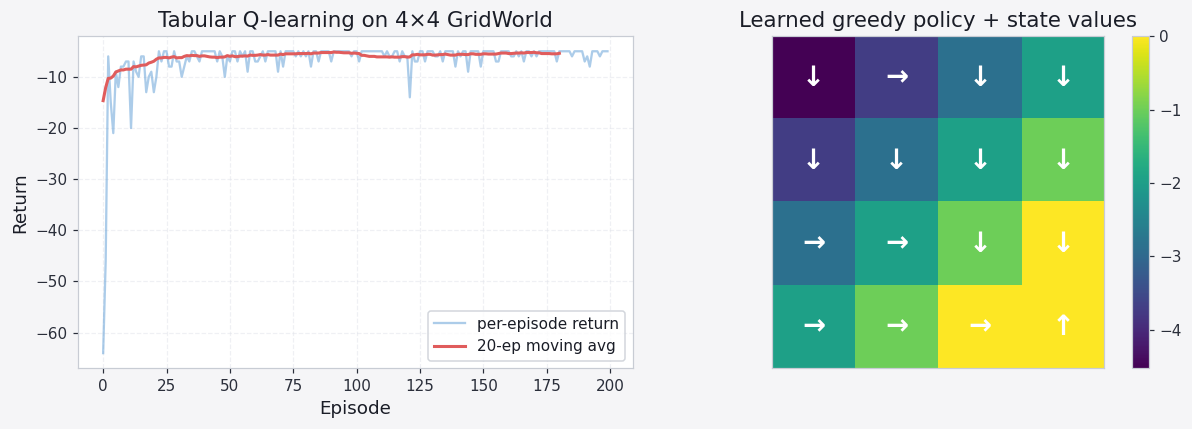

Best 20-ep moving-average return: -5.15


In [3]:
# Tabular Q-learning on a tiny GridWorld — reaches the goal in roughly 50 episodes.
np.random.seed(0)

# 4×4 grid, start (0,0), goal (3,3), step reward -1, goal +0
H, W = 4, 4
n_actions = 4  # up, down, left, right
deltas = [(-1,0),(1,0),(0,-1),(0,1)]

def step(s, a):
    r, c = divmod(s, W)
    dr, dc = deltas[a]
    nr, nc = max(0, min(H-1, r+dr)), max(0, min(W-1, c+dc))
    ns = nr*W + nc
    done = (ns == H*W-1)
    reward = 0 if done else -1
    return ns, reward, done

def run(alpha=0.5, gamma=0.95, eps=0.1, n_episodes=200):
    Q = np.zeros((H*W, n_actions))
    returns = []
    for ep in range(n_episodes):
        s, total, done = 0, 0, False
        steps = 0
        while not done and steps < 100:
            a = np.random.randint(n_actions) if np.random.rand() < eps else int(np.argmax(Q[s]))
            ns, r, done = step(s, a)
            Q[s, a] += alpha * (r + gamma * Q[ns].max() - Q[s, a])
            s = ns; total += r; steps += 1
        returns.append(total)
    return Q, np.array(returns)

Q, returns = run()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(returns, color=PALETTE[0], alpha=0.5, label='per-episode return')
ax.plot(np.convolve(returns, np.ones(20)/20, mode='valid'), color=PALETTE[1], lw=2, label='20-ep moving avg')
ax.set_xlabel('Episode'); ax.set_ylabel('Return')
ax.set_title('Tabular Q-learning on 4×4 GridWorld')
ax.legend(); ax.grid(True)

ax = axes[1]
V = Q.max(axis=1).reshape(H, W)
im = ax.imshow(V, cmap='viridis')
for i in range(H):
    for j in range(W):
        a = int(np.argmax(Q[i*W+j]))
        arrow = ['↑','↓','←','→'][a]
        ax.text(j, i, arrow, ha='center', va='center', color='white', fontsize=18, fontweight='bold')
ax.set_title('Learned greedy policy + state values')
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

_ma = np.convolve(returns, np.ones(20)/20, mode="valid")
print(f'Best 20-ep moving-average return: {_ma.max():.2f}')


---
## What we just saw

- A simple **table of Q-values** plus $\varepsilon$-greedy exploration is enough to solve a tiny MDP.
- The greedy policy converges to optimal arrows pointing from start toward goal.
- DQN ([notebook 34](illustrated_34_reinforcement_learning_dqn.ipynb)) replaces the table with a neural net for huge state spaces; PG ([notebook 35](illustrated_35_reinforcement_learning_policy_gradient.ipynb)) parameterises the policy directly to handle continuous actions.

> Lesson: scale up only when you must.
> Tabular Q-learning is the **clearest demonstration of TD learning**; reach for DQN/PG when the state or action space breaks the table.


---
## Summary

- Each algorithm in this category attacks a **different shape of problem**.
- The decision rule above is a heuristic, not a law — always benchmark.
- Read the linked deep-dive notebook for derivations, failure modes and exercises.

> Continue to the other recap notebooks: [Regression](illustrated_00_recap_regression.ipynb) ·
> [Classification](illustrated_00_recap_classification.ipynb) ·
> [Ensembles](illustrated_00_recap_ensembles.ipynb) ·
> [Clustering](illustrated_00_recap_clustering.ipynb) ·
> [Dim. Reduction](illustrated_00_recap_dim_reduction.ipynb) ·
> [Anomaly Detection](illustrated_00_recap_anomaly_detection.ipynb) ·
> [Time Series](illustrated_00_recap_time_series.ipynb) ·
> [RL](illustrated_00_recap_reinforcement_learning.ipynb).
